# **Project 2 : Fraud Detection**

## **Overview**


*   The main objective of this project (e.g., fraud detection based on historical data).
*   A brief explanation of the approaches used (Logistic Regression, Random Forest and AdaBoost).



**Kolom pada dataset**

---
1. trans_date_trans_time: Waktu transaksi. Dapat digunakan untuk mendeteksi pola waktu (misal transaksi yang sering terjadi pada waktu yang tidak wajar bisa dicurigai sebagai fraud).
2. cc_num: Nomor kartu kredit. Informasi penting terkait pengguna kartu, tetapi tidak langsung membantu mendeteksi fraud kecuali ada pola dari penggunaan kartu yang tidak biasa.
3. merchant: Nama merchant (penjual). Merchant tertentu mungkin lebih sering terlibat dalam transaksi fraud, sehingga bisa membantu mendeteksi risiko terkait merchant.
4. category: Kategori transaksi. Fraud mungkin lebih sering terjadi dalam kategori tertentu seperti barang mewah atau hiburan, yang memiliki nilai transaksi lebih tinggi.
5. amt: Jumlah uang dalam transaksi. Nilai transaksi yang sangat besar atau tidak sesuai dengan pola belanja biasanya bisa menjadi tanda fraud.
6. first: Nama depan pemegang kartu. Tidak terlalu relevan dalam mendeteksi fraud secara langsung.
7. last: Nama belakang pemegang kartu. Sama seperti first, tidak relevan secara langsung.
8. gender: Jenis kelamin pemegang kartu. Bisa digunakan untuk melihat pola demografis terkait fraud, meskipun tidak secara langsung mengindikasikan fraud.
9. street: Alamat jalan pemegang kartu. Dapat digunakan dalam deteksi anomali jika lokasi transaksi berbeda jauh dari alamat pemegang kartu.
10. city: Kota pemegang kartu. Sama seperti street, dapat digunakan untuk memeriksa ketidaksesuaian antara lokasi pemegang kartu dan transaksi.
11. state: Negara bagian pemegang kartu. Sama dengan city, bisa mendeteksi anomali lokasi.
12. zip: Kode pos pemegang kartu. Sama dengan city dan state, bisa membantu mendeteksi anomali geografis.
13. lat: Garis lintang lokasi pemegang kartu. Lokasi geografis dapat membantu mendeteksi ketidaksesuaian jika dibandingkan dengan lokasi transaksi.
14. long: Garis bujur lokasi pemegang kartu. Sama dengan lat, membantu mendeteksi lokasi.
15. city_pop: Populasi kota pemegang kartu. Bisa digunakan untuk memahami risiko terkait daerah, misalnya daerah padat penduduk mungkin memiliki lebih banyak transaksi dan risiko.
16. job: Pekerjaan pemegang kartu. Pekerjaan dengan penghasilan tinggi mungkin lebih rentan terhadap fraud karena lebih sering terlibat dalam transaksi besar.
17. dob: Tanggal lahir pemegang kartu. Usia pemegang kartu bisa menjadi faktor, misalnya kelompok usia tertentu mungkin lebih rentan terhadap fraud.
18. trans_num: ID unik untuk transaksi. Tidak relevan dalam deteksi fraud secara langsung.
19. unix_time: Waktu transaksi dalam format unix. Sama seperti trans_date_trans_time, membantu dalam menganalisis pola waktu.
20. merch_lat: Garis lintang merchant. Dapat digunakan untuk mendeteksi ketidaksesuaian antara lokasi merchant dan pemegang kartu.
21. merch_long: Garis bujur merchant. Sama seperti merch_lat, membantu mendeteksi anomali lokasi.
22. is_fraud: Label apakah transaksi adalah fraud (0 = tidak fraud, 1 = fraud). Ini adalah target yang perlu diprediksi.


## **Import Package**

In [8]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import warnings
import sklearn.exceptions
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import linear_model
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn import datasets, metrics, preprocessing, svm
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report,accuracy_score
#warnings.filterwarnings("ignore", category=sklearn.exceptions.UndefinedMetricWarning)



## **Loading the Dataset**

In [9]:
#read dataset from gdrive
from google.colab import drive
drive.mount('/content/drive')

url = ('/content/drive/MyDrive/Fundamental ML/Project Assignment/Project 2 - Fraud Detection/Dataset/fraudTrain.csv')

# loading data
df_fraud = pd.read_csv(url)

df_fraud

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [10]:
#Cek Data information
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [11]:
#Shape of Data
print(df_fraud.shape)

(1296675, 23)


In [12]:
df_fraud.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


# **Step-Step of Analysis**

In [13]:
# Action Items : Drop Kolom
unless_kolom = ['Unnamed: 0']
indetifer = ['cc_num', 'first', 'last', 'trans_num']

# Action Items : New Features, OHE , Label Encoder (bertingkat), < 20 drop
category = ['merchant', 'category', 'gender', 'street', 'city', 'state', 'zip', 'job', 'unix_time']

# Action Items : New Features = Distance
location = ['lat', 'long', 'merch_lat', 'merch_long']

# Action Items : New Features = Risk Time, Risk Day, Age
datetime = ['trans_date_trans_time', 'dob']

# Action Items : New Features : city_pop category, amt category
numerical = ['amt', 'city_pop']

target = ['is_fraud']

## **1. Preprocessing Data**



### 1.1 Checking Missing Value

In [14]:
df_fraud.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


### 1.2 Drop Column not Needed
unless_kolom = ['Unnamed: 0']
indetifer = ['cc_num', 'first', 'last', 'trans_num']

In [15]:
df_fraud.drop(unless_kolom, axis=1, inplace=True)


In [16]:
df_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [17]:
df_fraud.drop(indetifer, axis=1, inplace=True)

In [18]:
df_fraud.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0


## **2. Exploratory Data Analysis (EDA) and Feature Engineering**

### 2.1 New Features = Distance
location = ['lat', 'long', 'merch_lat', 'merch_long']

In [19]:
import numpy as np
from geopy.distance import geodesic

def calculate_distance(row):
  """Calculates the distance between two points using latitude and longitude."""
  try:
    coord1 = (row['lat'], row['long'])
    coord2 = (row['merch_lat'], row['merch_long'])
    return geodesic(coord1, coord2).km
  except:
    return np.nan  # Handle cases with missing location data

# Apply the function to create the 'Distance' column
df_fraud['distance'] = df_fraud.apply(calculate_distance, axis=1)

df_fraud.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,distance
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0,78.773821
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0,30.216618
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0,108.102912
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0,95.685115
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0,77.702395


### 2.2 New Features, OHE , Label Encoder > 20 drop
category = ['merchant', 'category', 'gender', 'street', 'city', 'state', 'zip', 'job', 'unix_time']


In [20]:
# Action Items : New Features, OHE , Label Encoder > 20 drop
category = ['merchant', 'category', 'gender', 'street', 'city', 'state', 'zip', 'job', 'unix_time']

for col in category:
    if df_fraud[col].nunique() > 20:
        print(f"Dropping column '{col}' because it has more than 20 unique values.")
        df_fraud.drop(col, axis=1, inplace=True)
    else:
        print(f"Column '{col}' has {df_fraud[col].nunique()} unique values.")


Dropping column 'merchant' because it has more than 20 unique values.
Column 'category' has 14 unique values.
Column 'gender' has 2 unique values.
Dropping column 'street' because it has more than 20 unique values.
Dropping column 'city' because it has more than 20 unique values.
Dropping column 'state' because it has more than 20 unique values.
Dropping column 'zip' because it has more than 20 unique values.
Dropping column 'job' because it has more than 20 unique values.
Dropping column 'unix_time' because it has more than 20 unique values.


<ipython-input-21-bd8152561708>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_fraud['gender'] = df_fraud['gender'].replace({'M': 2, 'F': 1})


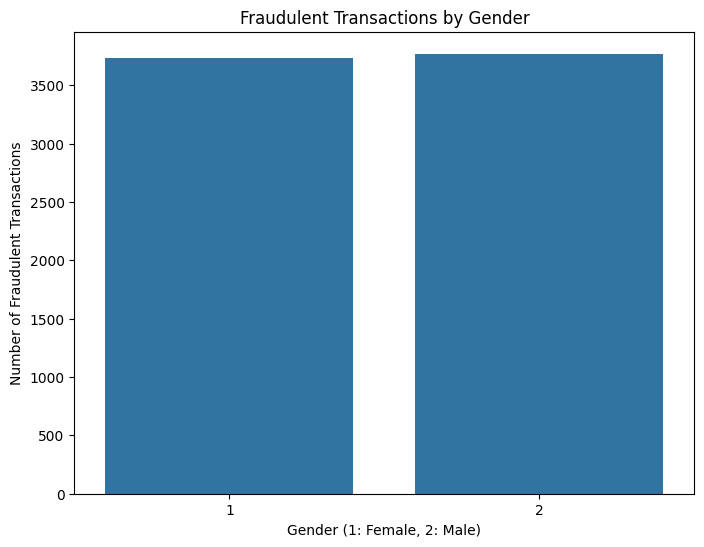

In [21]:
# prompt: create bar chart with gender is fraud = 1, gender change from male to 2 and female to 1

import matplotlib.pyplot as plt
# Replace 'gender' values
df_fraud['gender'] = df_fraud['gender'].replace({'M': 2, 'F': 1})

# Filter for fraudulent transactions and the specified gender
fraudulent_transactions = df_fraud[(df_fraud['is_fraud'] == 1)]

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=fraudulent_transactions)
plt.title('Fraudulent Transactions by Gender')
plt.xlabel('Gender (1: Female, 2: Male)')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()


In [22]:
df_fraud.head()

,trans_date_trans_time,category,amt,gender,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,distance
0,2019-01-01 00:00:18,misc_net,4.97,1,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0,78.773821
1,2019-01-01 00:00:44,grocery_pos,107.23,1,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0,30.216618
2,2019-01-01 00:00:51,entertainment,220.11,2,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0,108.102912
3,2019-01-01 00:01:16,gas_transport,45.00,2,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0,95.685115
4,2019-01-01 00:03:06,misc_pos,41.96,2,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0,77.702395


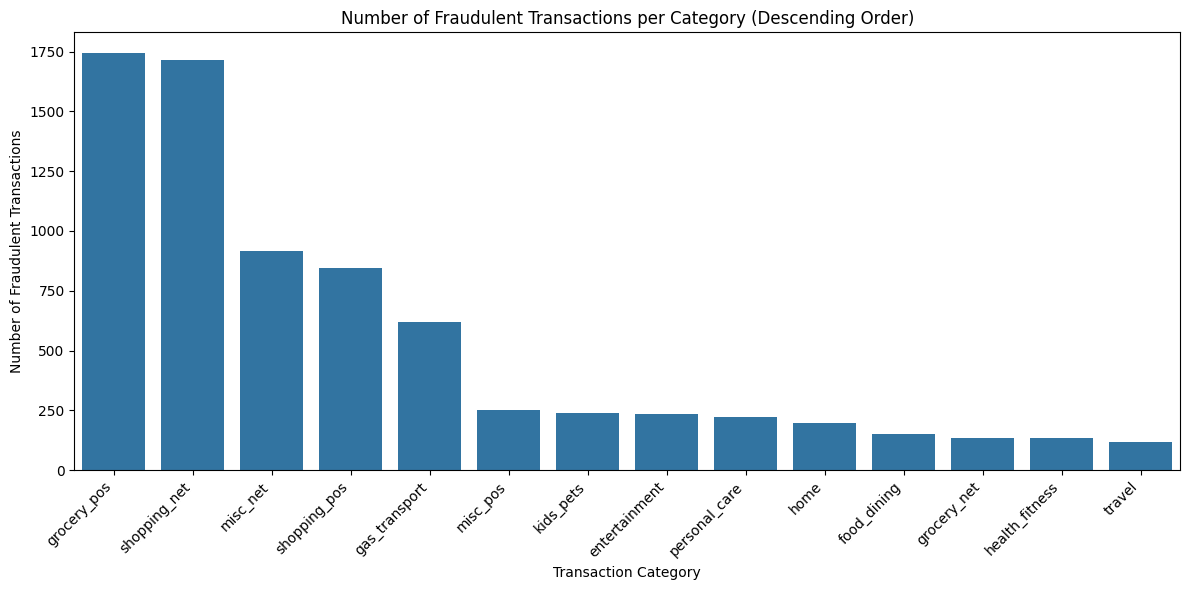

In [23]:
# prompt: create bar chart with category is fraud = 1 order by descending

# Assuming 'df_fraud' is your DataFrame and it's already been processed as shown in your provided code.

import matplotlib.pyplot as plt
import seaborn as sns

# Filter for fraudulent transactions
fraudulent_transactions = df_fraud[df_fraud['is_fraud'] == 1]

# Group by 'category' and count occurrences, then sort in descending order
category_counts = fraudulent_transactions['category'].value_counts().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Number of Fraudulent Transactions per Category (Descending Order)')
plt.xlabel('Transaction Category')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [24]:
# prompt: buatkan kolom risk category dengan definisi grocery pos, shopping net, misc net, shopping, gas transport menjadi risk category. Sisanya low category

# Create the 'risk_category' column based on the specified conditions
def categorize_risk(row):
    if row['category'] in ['grocery_pos', 'shopping_net', 'misc_net', 'shopping', 'gas_transport']:
        return 2 #'high_risk'
    else:
        return 1 #'low_risk'

df_fraud['risk_category'] = df_fraud.apply(categorize_risk, axis=1)

df_fraud.head()


,trans_date_trans_time,category,amt,gender,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,distance,risk_category
0,2019-01-01 00:00:18,misc_net,4.97,1,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0,78.773821,2
1,2019-01-01 00:00:44,grocery_pos,107.23,1,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0,30.216618,2
2,2019-01-01 00:00:51,entertainment,220.11,2,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0,108.102912,1
3,2019-01-01 00:01:16,gas_transport,45.00,2,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0,95.685115,2
4,2019-01-01 00:03:06,misc_pos,41.96,2,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0,77.702395,1


### 2.3 New Features = Risk Time, Risk Day, Age
datetime = ['trans_date_trans_time', 'dob']


In [25]:
# prompt: tolong buatkan feature baru dengan nama  Age dari pengurangan trans_date dan day of birth

import pandas as pd
# Convert 'trans_date_trans_time' to datetime objects
df_fraud['trans_date_trans_time'] = pd.to_datetime(df_fraud['trans_date_trans_time'])

# Convert 'dob' to datetime objects
df_fraud['dob'] = pd.to_datetime(df_fraud['dob'])

# Calculate age
df_fraud['age'] = (df_fraud['trans_date_trans_time'] - df_fraud['dob']).dt.days // 365

df_fraud.head()


,trans_date_trans_time,category,amt,gender,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,distance,risk_category,age
0,2019-01-01 00:00:18,misc_net,4.97,1,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0,78.773821,2,30
1,2019-01-01 00:00:44,grocery_pos,107.23,1,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0,30.216618,2,40
2,2019-01-01 00:00:51,entertainment,220.11,2,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0,108.102912,1,56
3,2019-01-01 00:01:16,gas_transport,45.00,2,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0,95.685115,2,52
4,2019-01-01 00:03:06,misc_pos,41.96,2,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0,77.702395,1,32


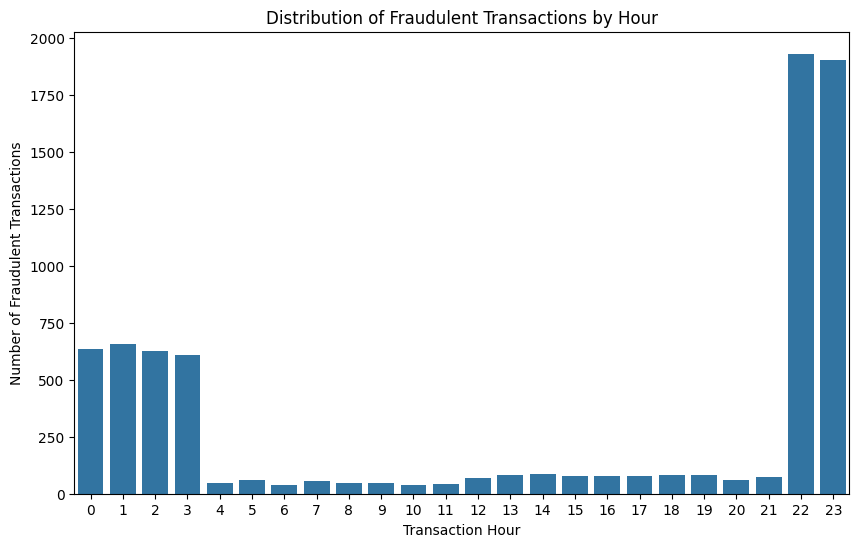

In [26]:
# prompt: convert trans_date_trans_time to hours and filter is_fraud = 1 and give bar chart

import matplotlib.pyplot as plt
# Extract hour from 'trans_date_trans_time'
df_fraud['transaction_hour'] = df_fraud['trans_date_trans_time'].dt.hour

# Filter for fraudulent transactions
fraudulent_transactions = df_fraud[df_fraud['is_fraud'] == 1]

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x='transaction_hour', data=fraudulent_transactions)
plt.title('Distribution of Fraudulent Transactions by Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()


Insight : Ditemukan transaksi yang tidak normal, kemungkinan terjadi transaksi fraud sekitar jam 22:00 s/d 03:00

In [27]:
# prompt: tolong buatkan feature baru dengan nama risk_time dari kolom trans_date_trans_time dengan regulasi jam 22 sampai 3 pagi risk time, sisanya adalah normal time

# Assuming df_fraud is your DataFrame and 'trans_date_trans_time' is already a datetime column

# Function to categorize transaction time as 'risk_time' or 'normal_time'
def categorize_risk_time(row):
    hour = row['transaction_hour']
    if 22 <= hour or hour <= 3:
        return 2 #'risk_time'
    else:
        return 1 #'normal_time'

# Apply the function to create the 'risk_time' column
df_fraud['risk_time'] = df_fraud.apply(categorize_risk_time, axis=1)

df_fraud.head()


,trans_date_trans_time,category,amt,gender,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,distance,risk_category,age,transaction_hour,risk_time
0,2019-01-01 00:00:18,misc_net,4.97,1,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0,78.773821,2,30,0,2
1,2019-01-01 00:00:44,grocery_pos,107.23,1,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0,30.216618,2,40,0,2
2,2019-01-01 00:00:51,entertainment,220.11,2,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0,108.102912,1,56,0,2
3,2019-01-01 00:01:16,gas_transport,45.00,2,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0,95.685115,2,52,0,2
4,2019-01-01 00:03:06,misc_pos,41.96,2,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0,77.702395,1,32,0,2


### 2.4 New Features : city_pop category, amt category
numerical = ['amt', 'city_pop']

In [28]:
# prompt: tolong buatkan feature baru dengan nama  city_pop category, amt category dengan pendekatan percentile

# Calculate quantiles for city_pop
city_pop_quantiles = df_fraud['city_pop'].quantile([0.25, 0.5, 0.75])

# Create city_pop categories
def categorize_city_pop(city_pop):
    if city_pop <= city_pop_quantiles[0.25]:
        return 1 #'Low'
    elif city_pop <= city_pop_quantiles[0.75]:
        return 2 #'Medium'
    else:
        return 3 #'High'

df_fraud['city_pop_category'] = df_fraud['city_pop'].apply(categorize_city_pop)


# Calculate quantiles for amt
amt_quantiles = df_fraud['amt'].quantile([0.25, 0.5, 0.75])

# Create amt categories
def categorize_amt(amt):
    if amt <= amt_quantiles[0.25]:
        return 1 #'Low'
    elif amt <= amt_quantiles[0.75]:
        return 2 #'Medium'
    else:
        return 3 #'High'

df_fraud['amt_category'] = df_fraud['amt'].apply(categorize_amt)

df_fraud.head()


,trans_date_trans_time,category,amt,gender,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,distance,risk_category,age,transaction_hour,risk_time,city_pop_category,amt_category
0,2019-01-01 00:00:18,misc_net,4.97,1,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0,78.773821,2,30,0,2,2,1
1,2019-01-01 00:00:44,grocery_pos,107.23,1,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0,30.216618,2,40,0,2,1,3
2,2019-01-01 00:00:51,entertainment,220.11,2,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0,108.102912,1,56,0,2,2,3
3,2019-01-01 00:01:16,gas_transport,45.00,2,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0,95.685115,2,52,0,2,2,2
4,2019-01-01 00:03:06,misc_pos,41.96,2,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0,77.702395,1,32,0,2,1,2


In [29]:
pd.set_option('display.max_columns', None)

In [30]:
df_fraud.head()

,trans_date_trans_time,category,amt,gender,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,distance,risk_category,age,transaction_hour,risk_time,city_pop_category,amt_category
0,2019-01-01 00:00:18,misc_net,4.97,1,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0,78.773821,2,30,0,2,2,1
1,2019-01-01 00:00:44,grocery_pos,107.23,1,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0,30.216618,2,40,0,2,1,3
2,2019-01-01 00:00:51,entertainment,220.11,2,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0,108.102912,1,56,0,2,2,3
3,2019-01-01 00:01:16,gas_transport,45.00,2,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0,95.685115,2,52,0,2,2,2
4,2019-01-01 00:03:06,misc_pos,41.96,2,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0,77.702395,1,32,0,2,1,2


## **3. Feature Selection**

In [31]:
df_fraud.columns

Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'lat', 'long',
       'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud', 'distance',
       'risk_category', 'age', 'transaction_hour', 'risk_time',
       'city_pop_category', 'amt_category'],
      dtype='object')

In [32]:
#seleksi kolom yang digunakan
df_fraud_final=df_fraud[['is_fraud','distance', 'gender',
       'city_pop', 'amt', 'age',
       'risk_time', 'risk_category']]

In [34]:
df_fraud_final.head()

,is_fraud,distance,gender,city_pop,amt,age,risk_time,risk_category
0,0,78.773821,1,3495,4.97,30,2,2
1,0,30.216618,1,149,107.23,40,2,2
2,0,108.102912,2,4154,220.11,56,2,1
3,0,95.685115,2,1939,45.00,52,2,2
4,0,77.702395,2,99,41.96,32,2,1


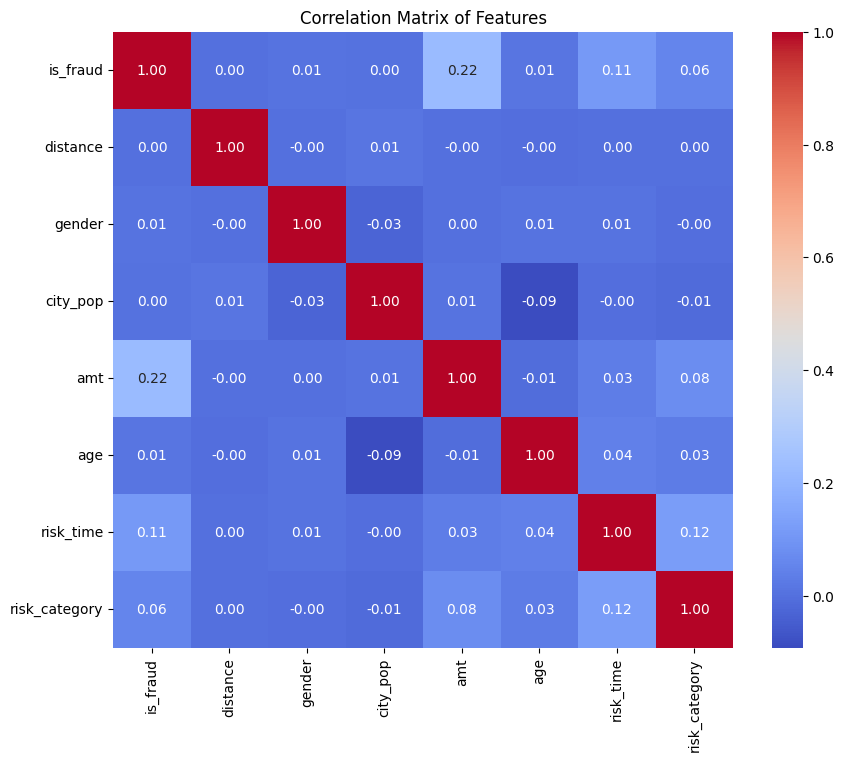

In [35]:
# prompt: create correlation matrix use plot

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df_fraud' is your DataFrame and it has been preprocessed as shown in your code.

# Calculate the correlation matrix
correlation_matrix = df_fraud_final.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


## **4. Train Test Split**

In [36]:
# prompt: lakukan train test split dengan stratified = y

X = df_fraud_final.drop('is_fraud', axis=1)
y = df_fraud_final['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)


## **5. Modelling**

### 5.1 Logistic Regression

              precision    recall  f1-score   support

           0       0.82      0.84      0.83   1031335
           1       0.84      0.82      0.83   1031335

    accuracy                           0.83   2062670
   macro avg       0.83      0.83      0.83   2062670
weighted avg       0.83      0.83      0.83   2062670



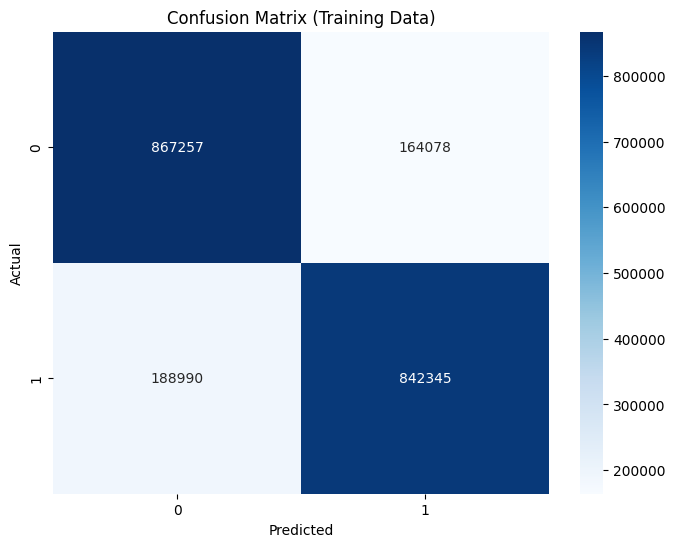

In [37]:
# prompt: buatlah model logistic regression beserta evaluasi clasification report untuk data training dengan menggunakan scaling smote beserta confusion matrix plot

import matplotlib.pyplot as plt
# Assuming X_train, y_train are already defined from the previous code

# Scaling
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# SMOTE
smote = SMOTE(random_state=123)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train_resampled, y_train_resampled)

# Prediction on training data
y_train_pred = logreg.predict(X_train_resampled)

# Classification Report
print(classification_report(y_train_resampled, y_train_pred))

# Confusion Matrix Plot
cm = confusion_matrix(y_train_resampled, y_train_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Training Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 5.2 Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1031335
           1       1.00      1.00      1.00   1031335

    accuracy                           1.00   2062670
   macro avg       1.00      1.00      1.00   2062670
weighted avg       1.00      1.00      1.00   2062670



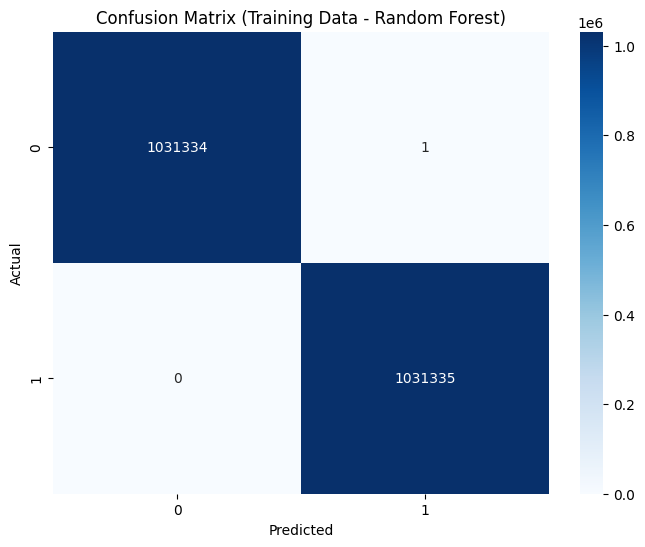

In [ ]:
# prompt: running dengan model random forest beserta evaluasi clasification report untuk data train beserta confusion matrix plot

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train, y_train, X_train_scaled, y_train_resampled are already defined from the previous code

# Random Forest
rf_classifier = RandomForestClassifier(random_state=123)
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Prediction on training data
y_train_pred_rf = rf_classifier.predict(X_train_resampled)

# Classification Report
print(classification_report(y_train_resampled, y_train_pred_rf))

# Confusion Matrix Plot
cm_rf = confusion_matrix(y_train_resampled, y_train_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Training Data - Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.81      0.53      0.64      1501

    accuracy                           1.00    259335
   macro avg       0.90      0.76      0.82    259335
weighted avg       1.00      1.00      1.00    259335



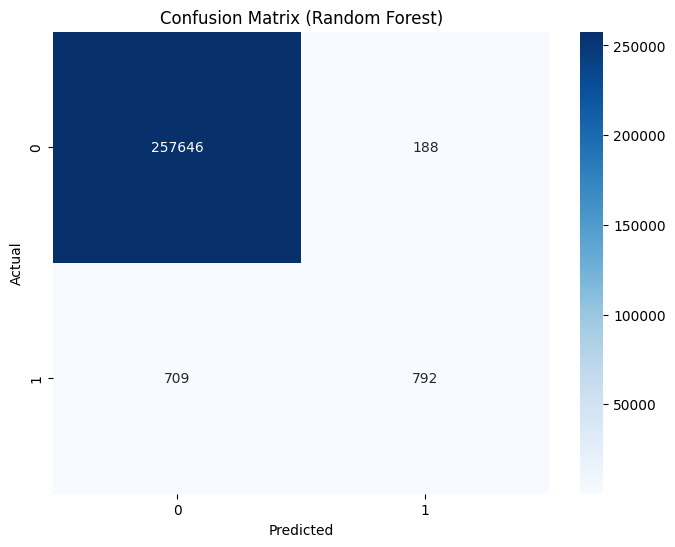

In [ ]:
# prompt: running dengan model random forest beserta evaluasi clasification report untuk data test beserta confusion matrix plot

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train, X_test, y_train, y_test are already defined from the previous code

# Initialize and train the Random Forest Classifier
# rf_classifier = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters here
rf_classifier = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model using classification_report
print(classification_report(y_test, y_pred_rf))

# Create and plot the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 5.3 AdaBoost

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.78      0.38      0.51      1501

    accuracy                           1.00    259335
   macro avg       0.89      0.69      0.75    259335
weighted avg       1.00      1.00      1.00    259335



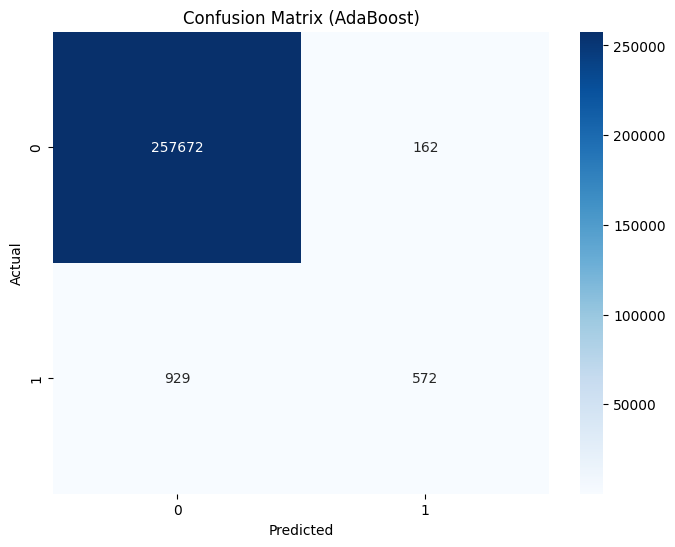

In [ ]:
# prompt: running dengan model adaboost beserta evaluasi clasification report untuk data test beserta confusion matrix plot

import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier

# Assuming X_train, X_test, y_train, y_test are already defined from the previous code

# Initialize and train the AdaBoost Classifier
ada_classifier = AdaBoostClassifier(random_state=42)  # You can adjust hyperparameters here
ada_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = ada_classifier.predict(X_test)

# Evaluate the model using classification_report
print(classification_report(y_test, y_pred_ada))

# Create and plot the confusion matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ada, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (AdaBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
